In [48]:
# Gerekli Kütüphaneleri Yükleyelim.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Veriyi okuyalım.
df = pd.read_csv('Telco-Customer-Churn.csv')

In [50]:
# Veri hakkında bilgi edinelim
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [51]:
# Total Charges sütunu hakkında bilgi edinelim
df.TotalCharges.info()

<class 'pandas.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype
--------------  -----
7043 non-null   str  
dtypes: str(1)
memory usage: 55.2 KB


In [ ]:
# TotalCharges kolonundaki boşluk (" ") karakterlerini NaN (eksik veri) ile değiştiriyoruz
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
# Artık metin (string) formatından ondalıklı sayı (float) formatına çevirebiliriz
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [53]:
# Eksik değerleri görelim
print("Eksik veri sayısı:\n", df.isnull().sum()[df.isnull().sum() > 0])

Eksik veri sayısı:
 TotalCharges    11
dtype: int64


In [54]:
# Eksik verileri (11 adet) sistemden çıkartabiliriz çünkü 7043 veri içinde çok küçük bir oran
df.dropna(inplace=True)

In [55]:
# Churn eden (ayrılan) ve etmeyen müşteri sayıları
print(df['Churn'].value_counts())
print("\nYüzdelik Dağılım:\n", df['Churn'].value_counts(normalize=True) * 100)


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Yüzdelik Dağılım:
 Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


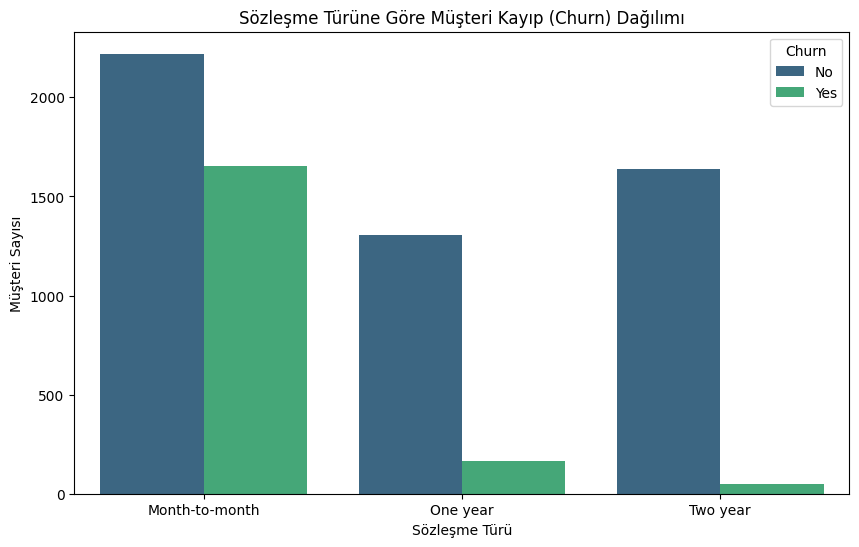

count               1869
unique                 3
top       Month-to-month
freq                1655
Name: Contract, dtype: object

In [56]:
# Sözleşme Türüne Göre Müşteri Kayıp Dağılımına Bakalım
plt.figure(figsize=(10, 6))
# Veriyi filtrelemeden direkt df'i kullanıp hue ile kırılım yaratıyoruz
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Sözleşme Türüne Göre Müşteri Kayıp (Churn) Dağılımı')
plt.xlabel('Sözleşme Türü')
plt.ylabel('Müşteri Sayısı')
plt.show()
# Churn yapan müşterilerin aylık ödeme istatistiklerini yazalım.
display(df[df['Churn'] == 'Yes']['Contract'].describe())

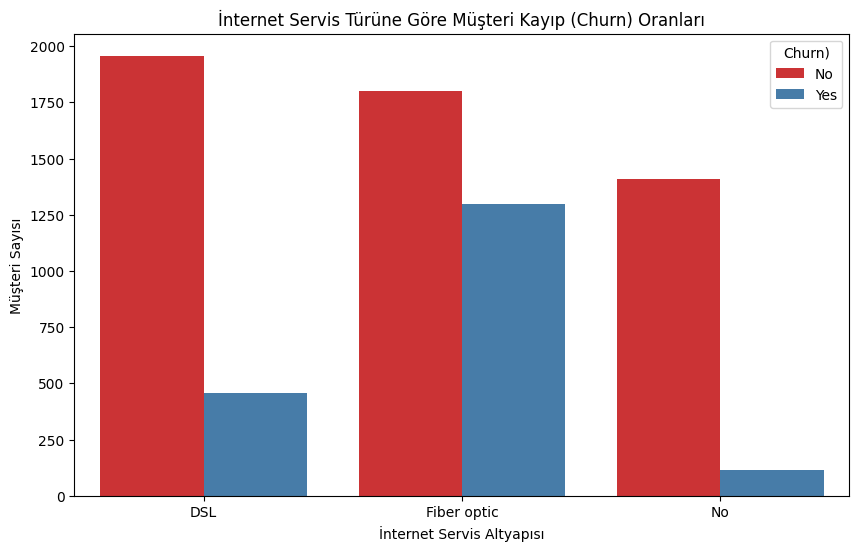

In [40]:
# İnternet Servis Türüne Göre Müşteri Kayıp Oranlarına Bakalım.
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set1')
plt.title('İnternet Servis Türüne Göre Müşteri Kayıp (Churn) Oranları')
plt.xlabel('İnternet Servis Altyapısı')
plt.ylabel('Müşteri Sayısı')

# Ekiplerin net görmesi için lejantı düzenleyelim
plt.legend(title='Churn)', labels=['No', 'Yes'])
plt.show()

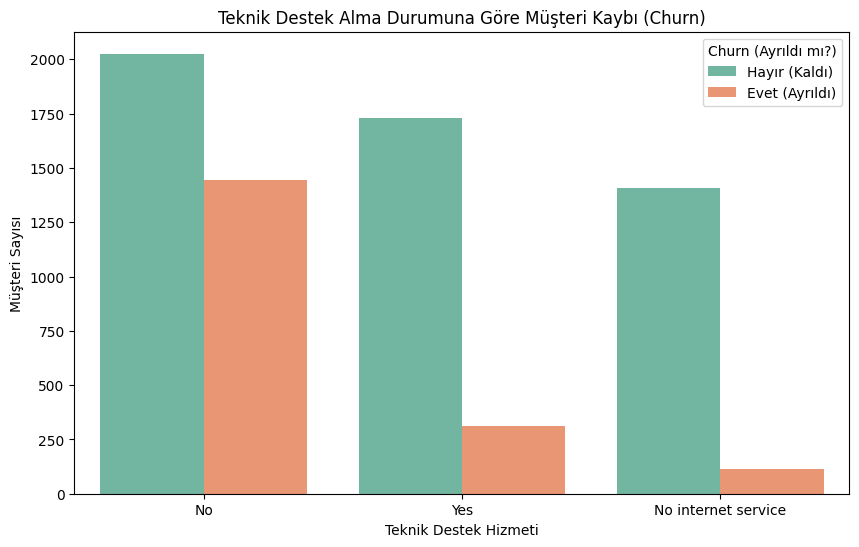

In [41]:
# Teknik Destek Alma Durumuna Göre Müşteri Kaybı 
plt.figure(figsize=(10, 6))
sns.countplot(x='TechSupport', hue='Churn', data=df, palette='Set2')
plt.title('Teknik Destek Alma Durumuna Göre Müşteri Kaybı (Churn)')
plt.xlabel('Teknik Destek Hizmeti')
plt.ylabel('Müşteri Sayısı')

plt.legend(title='Churn (Ayrıldı mı?)', labels=['Hayır (Kaldı)', 'Evet (Ayrıldı)'])
plt.show()

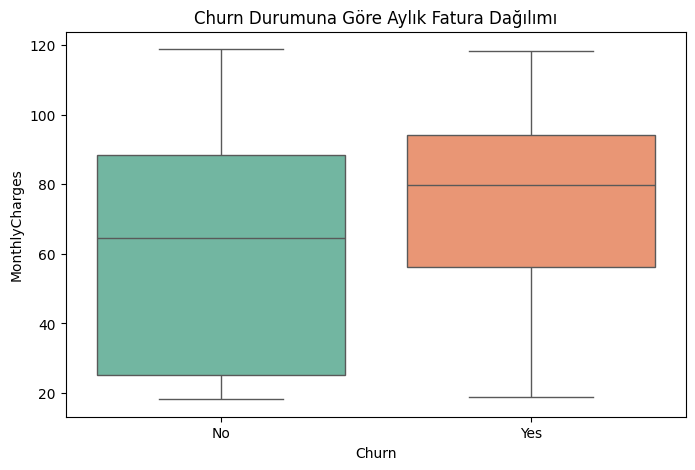

In [43]:
#Churn Durumuna Göre Aylık Fatura Dağılımına Bakalım.
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', hue='Churn', legend=False)
plt.title('Churn Durumuna Göre Aylık Fatura Dağılımı')
plt.show()